<a href="https://colab.research.google.com/github/Florida-devi/E-Commerce-page/blob/main/dl_imagedetection_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import os
from random import shuffle

In [25]:
TRAIN_DIR =r'C:\Users\ramsh\Documents\TRAIN'
TEST_DIR = r'C:\Users\ramsh\Documents\TEST'

In [26]:
IMG_SIZE = 120
MODEL_NAME = 'NIKESvsADIDAS'

In [27]:
def label_image(img):
    word_label = img.split('_')[0]

    if word_label == 'NIKE':
        return [1, 0]
    elif word_label == 'ADIDAS':
        return [0, 1]

In [28]:
import os
print(os.listdir())

['.config', 'test', 'ADIDAS_9.png', 'train', '.ipynb_checkpoints', 'sample_data']


In [29]:
import os
print(os.listdir("train"))

['ADIDAS_20.png', 'NIKE_15.png', 'ADIDAS_19.png', 'NIKE_6.png', 'ADIDAS_38.png', 'ADIDAS_48.png', 'NIKE_41.png', 'NIKE_18.png', 'NIKE_27.png', 'ADIDAS_16.png', 'NIKE_2.png', 'ADIDAS_18.png', 'NIKE_11.png', 'NIKE_37.png', 'ADIDAS_8.png', 'NIKE_50.png', 'ADIDAS_49.png', 'ADIDAS_50.png', 'NIKE_38.png', 'NIKE_29.png', 'NIKE_1.png', 'NIKE_47.png', 'ADIDAS_9.png', 'NIKE_49.png', 'ADIDAS_34.png', 'NIKE_19.png', 'ADIDAS_27.png', 'ADIDAS_26.png', 'ADIDAS_35.png', 'NIKE_46.png', 'ADIDAS_4.png', 'ADIDAS_39.png', 'NIKE_33.png', 'NIKE_31.png', 'ADIDAS_14.png', 'ADIDAS_29.png', 'ADIDAS_6.png', 'NIKE_40.png', 'ADIDAS_25.png', 'NIKE_39.png', 'NIKE_21.png', 'NIKE_35.png', 'ADIDAS_7.png', 'ADIDAS_33.png', 'NIKE_28.png', 'NIKE_7.png', 'NIKE_12.png', 'NIKE_9.png', 'ADIDAS_41.png', 'ADIDAS_1.png', 'NIKE_44.png', 'NIKE_26.png', 'NIKE_43.png', 'ADIDAS_43.png', 'ADIDAS_22.png', 'NIKE_32.png', 'ADIDAS_10.png', 'ADIDAS_46.png', 'ADIDAS_47.png', 'NIKE_8.png', 'ADIDAS_36.png', 'NIKE_36.png', 'ADIDAS_37.png', 'ADI

In [30]:
import os
from tqdm import tqdm
from PIL import Image
import numpy as np
from random import shuffle

TRAIN_DIR = "train"
IMG_SIZE = 224

train_data = []

def label_image(filename):
    if "nike" in filename.lower():
        return [1]
    else:
        return [0]

for img_name in tqdm(os.listdir(TRAIN_DIR)):
    path = os.path.join(TRAIN_DIR, img_name)

    try:
        img = Image.open(path)
        img = img.convert('L')
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

        label = label_image(img_name)

        train_data.append([np.array(img), np.array(label)])

    except:
        print("Error:", path)

shuffle(train_data)

100%|██████████| 100/100 [00:00<00:00, 273.51it/s]


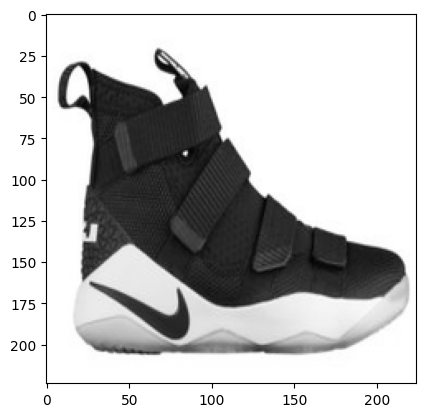

In [31]:
plt.imshow(train_data[35][0], cmap='gist_gray')
plt.show()

In [32]:
import keras
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten

In [33]:
from keras.layers import Input

model = Sequential()

model.add(Input(shape=(120,120,1)))

model.add(Conv2D(32, (5,5), activation='relu'))
model.add(Conv2D(32, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (5,5), activation='relu'))
model.add(Conv2D(64, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (5,5), activation='relu'))
model.add(Conv2D(64, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
X = np.array([i[0] for i in train_data]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array([i[1] for i in train_data])

X = X / 255.0

In [35]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),   # ✅ REQUIRED

    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4040 - loss: 8.5895
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5051 - loss: 0.9667
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5253 - loss: 0.6902
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5051 - loss: 0.6723
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7273 - loss: 0.6325
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6667 - loss: 0.6264
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8485 - loss: 0.5050
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8889 - loss: 0.4246
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9091 - loss: 0.3286
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9394 - loss: 0.2461


In [15]:
from google.colab import files
uploaded = files.upload()

Saving ADIDAS_9.png to ADIDAS_9.png


In [16]:
import os
print(os.listdir())

['.config', 'test', 'ADIDAS_9.png', 'train', '.ipynb_checkpoints', 'sample_data']


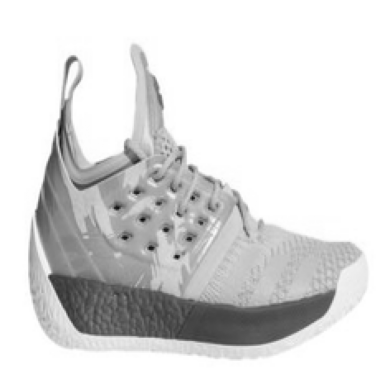

In [17]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("ADIDAS_9.png")
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

plt.imshow(np.array(img), cmap='gray')
plt.axis('off')
plt.show()

In [18]:
model.predict(np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


array([[0.]], dtype=float32)

In [19]:
import os
print(os.listdir())

['.config', 'test', 'ADIDAS_9.png', 'train', '.ipynb_checkpoints', 'sample_data']


In [21]:
img = Image.open("ADIDAS_9.png")

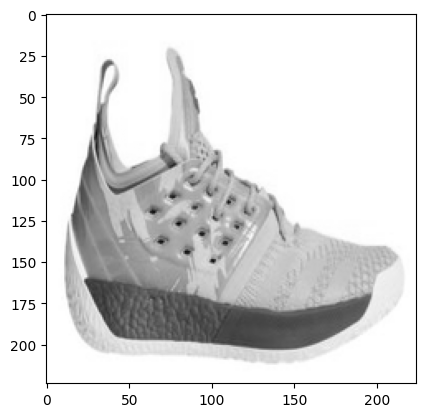

In [22]:
img = Image.open(r'ADIDAS_9.png')
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

plt.imshow(np.array(img), cmap='gist_gray')
plt.show()

In [23]:
model.predict(np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[0.]], dtype=float32)